# 03 — Price Formation

**Market Microstructure Simulation — Notebook 3**

---

## Mục tiêu

Notebook này trả lời câu hỏi trung tâm của market microstructure:

> **Giá thị trường hình thành như thế nào từ dòng lệnh?**

| Concept | Câu hỏi | Tool |
|---|---|---|
| **Glosten-Milgrom** | Informed traders ảnh hưởng giá thế nào? | `OrderFlowGenerator`, `PriceImpactModel` |
| **Price discovery** | Giá thị trường hội tụ về fundamental thế nào? | `FundamentalProcess` + `OrderBook` |
| **OFI → ΔPrice** | Imbalance dự báo giá ngắn hạn? | `OFICalculator`, OLS regression |
| **Permanent vs Temporary impact** | Phần nào của impact tồn tại lâu dài? | `PriceImpactModel` |
| **Trade classification** | Tick rule vs Lee-Ready accuracy | `TradeClassifier` |
| **VPIN** | Đo toxic flow & dự báo flash crash | `VPINCalculator` |

---

### Dependency
```
structure/
├── state/orderbook.py
├── mechanism/order_flow.py    ← module chính notebook này
└── simulation/market_simulation.py
```

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

from src.structure import (
    PoissonArrivalProcess, OrderSizeDistribution,
    OrderFlowGenerator, TradeClassifier,
    OFICalculator, VPINCalculator, TraderType,
    PriceImpactModel,FundamentalProcess,
)

print("✓ Imports OK")

✓ Imports OK


---
## Part 1 — Glosten-Milgrom: Tại sao informed traders làm spread rộng ra?

**Glosten-Milgrom (1985)** chứng minh rằng trong thị trường có asymmetric information:

- Dealer không biết ai là informed, ai là noise
- Informed traders luôn trade có lợi cho họ (bất lợi cho dealer)
- Dealer mở rộng spread để bù đắp tổn thất từ informed traders

$$\text{Spread} = f(\mu, \text{prob\_informed})$$

Khi `prob_informed` tăng → dealer bị adverse selection nhiều hơn → spread phải rộng hơn.

In [16]:
rng = np.random.default_rng(42)

def simulate_glosten_milgrom(
    prob_informed: float,
    n_steps: int = 500,
    true_value: float = 100.0,
    signal_strength: float = 0.85,
    half_spread_init: float = 0.10,
    rng_seed: int = 42,
):
    """
    Mô phỏng đơn giản hóa Glosten-Milgrom:
    - Dealer update belief về true value sau mỗi trade
    - Belief update theo Bayes: informed trade là signal về value
    - Spread = 2 * half_spread, half_spread tỷ lệ với uncertainty
    """
    rng_local = np.random.default_rng(rng_seed)

    size_dist = OrderSizeDistribution(distribution="lognormal", mu_log=2.0, sigma_log=0.5, rng=rng_local)
    arrival   = PoissonArrivalProcess(lambda_buy=5.0, lambda_sell=5.0, dt=1.0, rng=rng_local)
    gen       = OrderFlowGenerator(
        prob_informed=prob_informed,
        signal_strength=signal_strength,
        arrival_process=arrival,
        size_dist=size_dist,
        limit_ratio=0.3,
        rng=rng_local,
    )

    # Dealer's belief about fundamental
    belief = true_value
    half_spread = half_spread_init

    prices, spreads, dealer_pnl = [true_value], [2 * half_spread], [0.0]
    informed_count, noise_count = 0, 0
    adverse_pnl = 0.0

    for step in range(n_steps):
        gen.update_signal()  # fundamental value bước ngẫu nhiên

        # True value random walk nhỏ
        true_value += rng_local.normal(0, 0.02)

        # Dealer posts quotes
        bid = belief - half_spread
        ask = belief + half_spread

        # Generate một lệnh
        event = gen._make_event(float(step), "bid", belief)

        is_informed = (event.trader_type == TraderType.INFORMED)
        trade_sign = gen._signal if is_informed else rng_local.choice([-1, 1])

        # Execution: informed trade against dealer at ask(buy) or bid(sell)
        if trade_sign == 1:   # buy → hits ask
            exec_price = ask
            dealer_side_pnl = exec_price - true_value  # dealer sold at ask, true value is higher if informed
        else:                  # sell → hits bid
            exec_price = bid
            dealer_side_pnl = true_value - exec_price

        adverse_pnl += dealer_side_pnl

        # Bayesian belief update: informed trade shifts belief toward signal
        if is_informed:
            informed_count += 1
            learning_rate = prob_informed * signal_strength
            belief += trade_sign * learning_rate * 0.05
        else:
            noise_count += 1

        # GM equilibrium spread: half_spread = base * (1 + scale * prob_informed)
        # Dealer prices in the probability of adverse selection analytically
        half_spread = half_spread_init * (1.0 + 3.0 * prob_informed * signal_strength)

        prices.append(belief)
        spreads.append(2 * half_spread)
        dealer_pnl.append(adverse_pnl)

    return {
        "prices": np.array(prices),
        "spreads": np.array(spreads),
        "dealer_pnl": np.array(dealer_pnl),
        "informed_count": informed_count,
        "noise_count": noise_count,
        "final_spread": spreads[-1],
    }


# Chạy với 3 mức informed trader
scenarios_gm = {
    "5% informed":  simulate_glosten_milgrom(prob_informed=0.05),
    "20% informed": simulate_glosten_milgrom(prob_informed=0.20),
    "40% informed": simulate_glosten_milgrom(prob_informed=0.40),
}

for name, res in scenarios_gm.items():
    print(f"{name}: final spread={res['final_spread']:.4f}, "
          f"informed trades={res['informed_count']}, noise={res['noise_count']}")

5% informed: final spread=0.2255, informed trades=29, noise=471
20% informed: final spread=0.3020, informed trades=124, noise=376
40% informed: final spread=0.4040, informed trades=222, noise=278


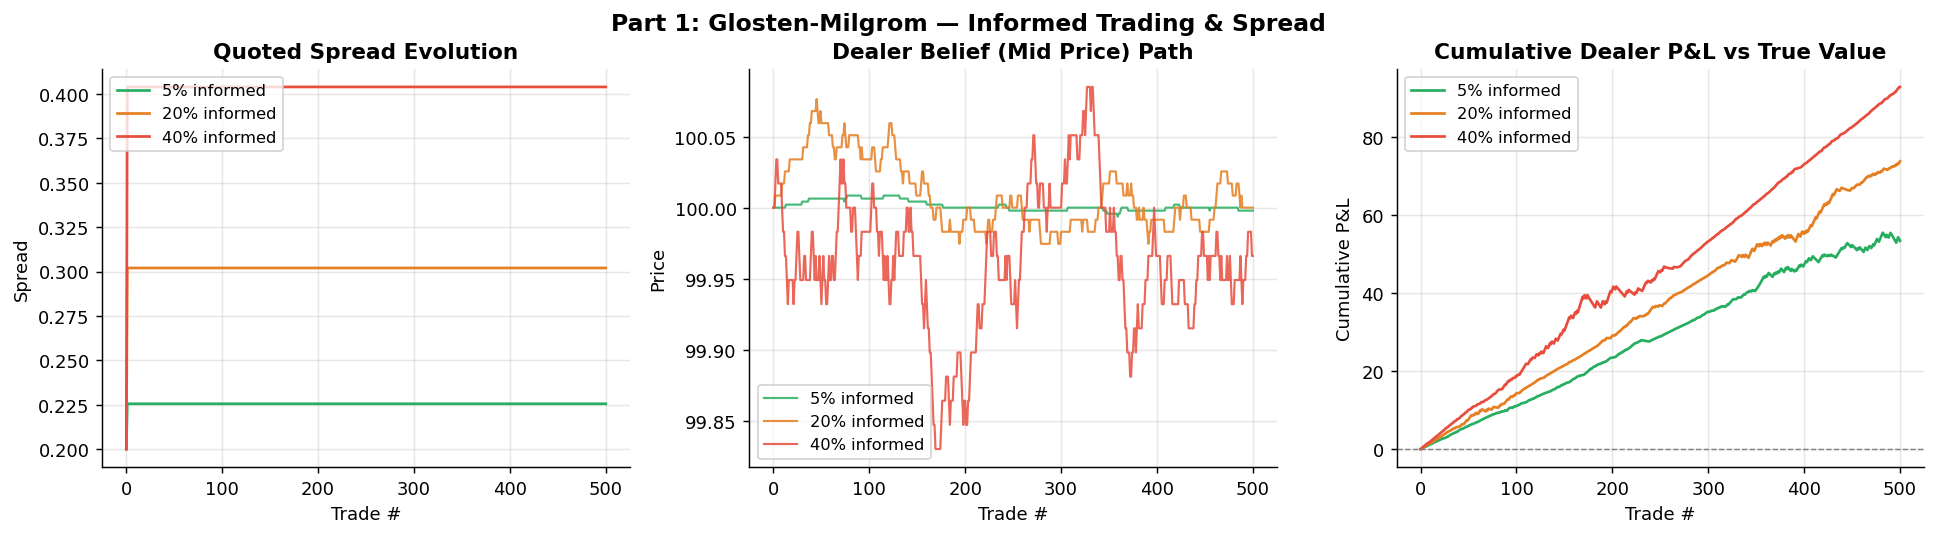

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#27ae60", "#e67e22", "#e74c3c"]

# 1. Spread evolution
ax = axes[0]
for (name, res), color in zip(scenarios_gm.items(), colors):
    ax.plot(res["spreads"], lw=1.5, color=color, label=name)
ax.set_title("Quoted Spread Evolution", fontweight="bold")
ax.set_xlabel("Trade #")
ax.set_ylabel("Spread")
ax.legend(fontsize=9)

# 2. Belief (mid price) paths
ax = axes[1]
for (name, res), color in zip(scenarios_gm.items(), colors):
    ax.plot(res["prices"], lw=1.2, color=color, alpha=0.85, label=name)
ax.set_title("Dealer Belief (Mid Price) Path", fontweight="bold")
ax.set_xlabel("Trade #")
ax.set_ylabel("Price")
ax.legend(fontsize=9)

# 3. Cumulative dealer P&L
ax = axes[2]
for (name, res), color in zip(scenarios_gm.items(), colors):
    ax.plot(res["dealer_pnl"], lw=1.5, color=color, label=name)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Cumulative Dealer P&L vs True Value", fontweight="bold")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative P&L")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 1: Glosten-Milgrom — Informed Trading & Spread", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- Khi `prob_informed` tăng, spread mở rộng dần theo thời gian để bù adverse selection.
- Dealer P&L xấu đi rõ rệt khi tỷ lệ informed cao — họ liên tục bán thấp/mua cao so với true value.
- Đây là lý do thực tế: spread ở các asset ít thanh khoản, ít được theo dõi → rộng hơn.

---
## Part 2 — Price Discovery: Giá thị trường hội tụ về fundamental

**Price discovery** = quá trình thị trường tích hợp thông tin vào giá.

Chúng ta so sánh hai quá trình:
- `fundamental(t)` = giá trị nội tại thực sự (GBM)
- `mid_price(t)` = giá thị trường quan sát được

**Pricing error** = `mid − fundamental` → đo độ lệch và tốc độ hội tụ.

In [18]:
rng2 = np.random.default_rng(7)
N    = 600
S0   = 100.0

# Fundamental process: GBM với vol thấp
fp = FundamentalProcess(model="gbm", S0=S0, mu=0.0, sigma=0.25,
                        dt=1/(252*390), rng=rng2)
fundamentals = fp.simulate(N)

# Market price = fundamental + noise + lagged adjustment
# Lag parameter: thị trường điều chỉnh chậm về fundamental
def simulate_price_discovery(fundamentals, adjustment_speed=0.3, noise_vol=0.02, rng=None):
    rng = rng or np.random.default_rng()
    N = len(fundamentals)
    mid = np.zeros(N)
    mid[0] = fundamentals[0]
    for t in range(1, N):
        # Error correction: mid adjusts toward fundamental
        error = fundamentals[t] - mid[t-1]
        noise = rng.normal(0, noise_vol)
        mid[t] = mid[t-1] + adjustment_speed * error + noise
    return mid

# Ba tốc độ điều chỉnh
mid_fast   = simulate_price_discovery(fundamentals, adjustment_speed=0.8, noise_vol=0.015, rng=np.random.default_rng(1))
mid_medium = simulate_price_discovery(fundamentals, adjustment_speed=0.3, noise_vol=0.020, rng=np.random.default_rng(2))
mid_slow   = simulate_price_discovery(fundamentals, adjustment_speed=0.1, noise_vol=0.025, rng=np.random.default_rng(3))

# Pricing error
err_fast   = mid_fast   - fundamentals
err_medium = mid_medium - fundamentals
err_slow   = mid_slow   - fundamentals

# Information share (Hasbrouck 1995 proxy)
# IS ≈ 1 - var(pricing_error) / var(fundamental)
var_f = np.var(np.diff(fundamentals))
def info_share(mid, fundamental):
    var_err = np.var(np.diff(mid - fundamental))
    return max(0.0, 1 - var_err / (var_f + 1e-10))

print("Information Share (Hasbrouck proxy):")
print(f"  Fast adjustment  (α=0.8): IS = {info_share(mid_fast,   fundamentals):.3f}")
print(f"  Medium adjustment(α=0.3): IS = {info_share(mid_medium, fundamentals):.3f}")
print(f"  Slow adjustment  (α=0.1): IS = {info_share(mid_slow,   fundamentals):.3f}")
print()
print("Pricing Error Statistics:")
for name, err in [("Fast", err_fast), ("Medium", err_medium), ("Slow", err_slow)]:
    print(f"  {name}: mean={np.mean(err):.4f}, std={np.std(err):.4f}, max_abs={np.max(np.abs(err)):.4f}")

Information Share (Hasbrouck proxy):
  Fast adjustment  (α=0.8): IS = 0.853
  Medium adjustment(α=0.3): IS = 0.327
  Slow adjustment  (α=0.1): IS = 0.000

Pricing Error Statistics:
  Fast: mean=0.0018, std=0.0208, max_abs=0.0626
  Medium: mean=0.0203, std=0.0726, max_abs=0.2860
  Slow: mean=0.1093, std=0.1612, max_abs=0.5330


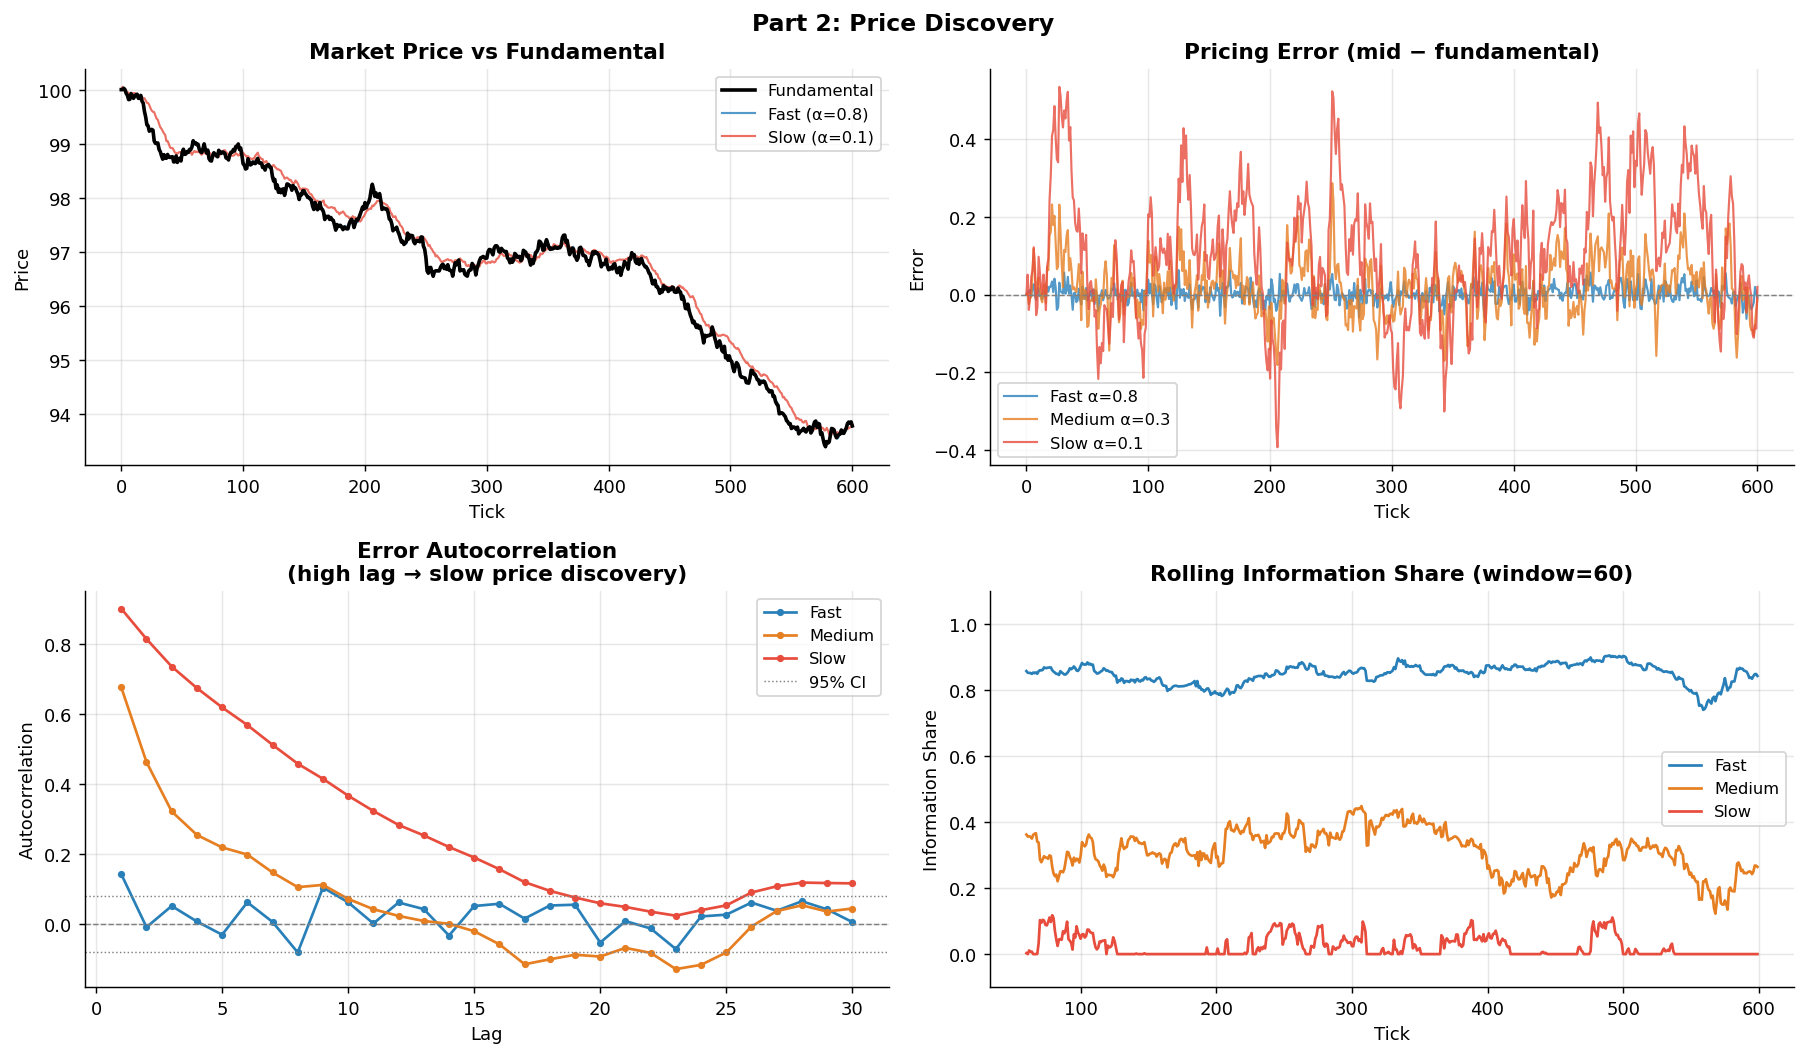

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

t_axis = np.arange(N)
colors_disc = ["#2980b9", "#e67e22", "#e74c3c"]

# 1. Price paths vs fundamental
ax = axes[0, 0]
ax.plot(fundamentals, color="black", lw=2, label="Fundamental", zorder=5)
ax.plot(mid_fast,   lw=1.2, color=colors_disc[0], alpha=0.8, label="Fast (α=0.8)")
ax.plot(mid_slow,   lw=1.2, color=colors_disc[2], alpha=0.8, label="Slow (α=0.1)")
ax.set_title("Market Price vs Fundamental", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Price")
ax.legend(fontsize=9)

# 2. Pricing error
ax = axes[0, 1]
for (name, err, alpha_val), color in zip(
    [("Fast α=0.8", err_fast, 0.8), ("Medium α=0.3", err_medium, 0.3), ("Slow α=0.1", err_slow, 0.1)],
    colors_disc
):
    ax.plot(err, lw=1.2, color=color, alpha=0.8, label=name)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Pricing Error (mid − fundamental)", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Error")
ax.legend(fontsize=9)

# 3. Error autocorrelation (persistence of mispricing)
ax = axes[1, 0]
max_lag = 30
lags = np.arange(1, max_lag + 1)

def autocorr(x, lag):
    x_centered = x - np.mean(x)
    return np.corrcoef(x_centered[:-lag], x_centered[lag:])[0, 1]

for (name, err), color in zip(
    [("Fast", err_fast), ("Medium", err_medium), ("Slow", err_slow)],
    colors_disc
):
    acf = [autocorr(err, l) for l in lags]
    ax.plot(lags, acf, lw=1.5, color=color, label=name, marker="o", markersize=3)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(1.96/np.sqrt(N), color="gray", lw=0.8, ls=":", label="95% CI")
ax.axhline(-1.96/np.sqrt(N), color="gray", lw=0.8, ls=":")
ax.set_title("Error Autocorrelation\n(high lag → slow price discovery)", fontweight="bold")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend(fontsize=9)

# 4. Rolling information share
ax = axes[1, 1]
window = 60
for (name, mid), color in zip(
    [("Fast", mid_fast), ("Medium", mid_medium), ("Slow", mid_slow)],
    colors_disc
):
    is_rolling = []
    for i in range(window, N):
        f_w = fundamentals[i-window:i]
        m_w = mid[i-window:i]
        var_f_w = np.var(np.diff(f_w)) + 1e-10
        var_e_w = np.var(np.diff(m_w - f_w))
        is_rolling.append(max(0.0, 1 - var_e_w / var_f_w))
    ax.plot(range(window, N), is_rolling, lw=1.5, color=color, label=name)
ax.set_title("Rolling Information Share (window=60)", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Information Share")
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 2: Price Discovery", y=1.01, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Pricing error** của thị trường chậm (α=0.1) có autocorrelation cao và kéo dài → mispricing tồn tại lâu → cơ hội arbitrage.
- **Information Share** cao → thị trường incorporate thông tin nhanh → efficient hơn.
- Tốc độ price discovery phụ thuộc vào tỷ lệ informed traders và market maker learning speed.

---
## Part 3 — OFI dự báo giá ngắn hạn

**Cont, Kukanov & Stoikov (2014)** chứng minh:

$$\Delta P_t = \beta \cdot \text{OFI}_t + \varepsilon_t$$

OFI (Order Flow Imbalance) đo thay đổi queue tại best bid/ask và có predictive power về price change trong vài giây tiếp theo.

In [20]:
rng3 = np.random.default_rng(13)
N_ofi = 800

# Mô phỏng order book dynamics
mid   = 100.0
tick  = 0.05

ofi_calc  = OFICalculator()
ofi_vals  = []
dp_vals   = []   # price changes
mid_vals  = [mid]
bid_depth_vals = []
ask_depth_vals = []

# State
bid_price = mid - tick
ask_price = mid + tick
bid_qty   = rng3.uniform(80, 120)
ask_qty   = rng3.uniform(80, 120)

for t in range(N_ofi):
    # Simulate order book update
    # Net buying pressure causes bid to improve or ask to get hit
    buy_pressure = rng3.normal(0, 1)

    if buy_pressure > 0.8:    # strong buy: ask price stays, ask qty decreases
        ask_qty   = max(5, ask_qty - rng3.uniform(10, 40))
        if ask_qty < 20:       # price moves up
            mid += tick
            bid_price += tick; ask_price += tick
            bid_qty = rng3.uniform(80, 120)
            ask_qty = rng3.uniform(80, 120)
    elif buy_pressure < -0.8: # strong sell
        bid_qty   = max(5, bid_qty - rng3.uniform(10, 40))
        if bid_qty < 20:
            mid -= tick
            bid_price -= tick; ask_price -= tick
            bid_qty = rng3.uniform(80, 120)
            ask_qty = rng3.uniform(80, 120)
    else:                      # normal: quantities replenish/decay
        bid_qty += rng3.normal(0, 10)
        ask_qty += rng3.normal(0, 10)
        bid_qty = np.clip(bid_qty, 10, 300)
        ask_qty = np.clip(ask_qty, 10, 300)

    # OFI update
    ofi = ofi_calc.update(bid_price, bid_qty, ask_price, ask_qty)
    if ofi is not None:
        ofi_vals.append(ofi)
        dp_vals.append(mid - mid_vals[-1])

    mid_vals.append(mid)
    bid_depth_vals.append(bid_qty)
    ask_depth_vals.append(ask_qty)

ofi_arr = np.array(ofi_vals)
dp_arr  = np.array(dp_vals)

# OLS: ΔP = β * OFI + ε
def ols(y, x):
    x_c = x - np.mean(x)
    y_c = y - np.mean(y)
    beta = np.dot(x_c, y_c) / (np.dot(x_c, x_c) + 1e-12)
    y_hat = beta * x_c + np.mean(y)
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return beta, r2, y_hat

beta, r2, dp_hat = ols(dp_arr, ofi_arr)

# Lead-lag: OFI at t predicts ΔP at t+k
max_lead = 10
lead_r2 = []
for lead in range(0, max_lead + 1):
    if lead == 0:
        lead_r2.append(r2)
    else:
        ofi_lagged = ofi_arr[:-lead]
        dp_future  = dp_arr[lead:]
        n = min(len(ofi_lagged), len(dp_future))
        _, r2_lead, _ = ols(dp_future[:n], ofi_lagged[:n])
        lead_r2.append(r2_lead)

print(f"OFI → ΔPrice regression:")
print(f"  β (OFI coefficient) = {beta:.6f}")
print(f"  R²                  = {r2:.4f}")
print(f"  Cumulative OFI range: [{ofi_calc.cumulative_ofi().min():.1f}, {ofi_calc.cumulative_ofi().max():.1f}]")

OFI → ΔPrice regression:
  β (OFI coefficient) = 0.000252
  R²                  = 0.7943
  Cumulative OFI range: [-3059.0, 532.2]


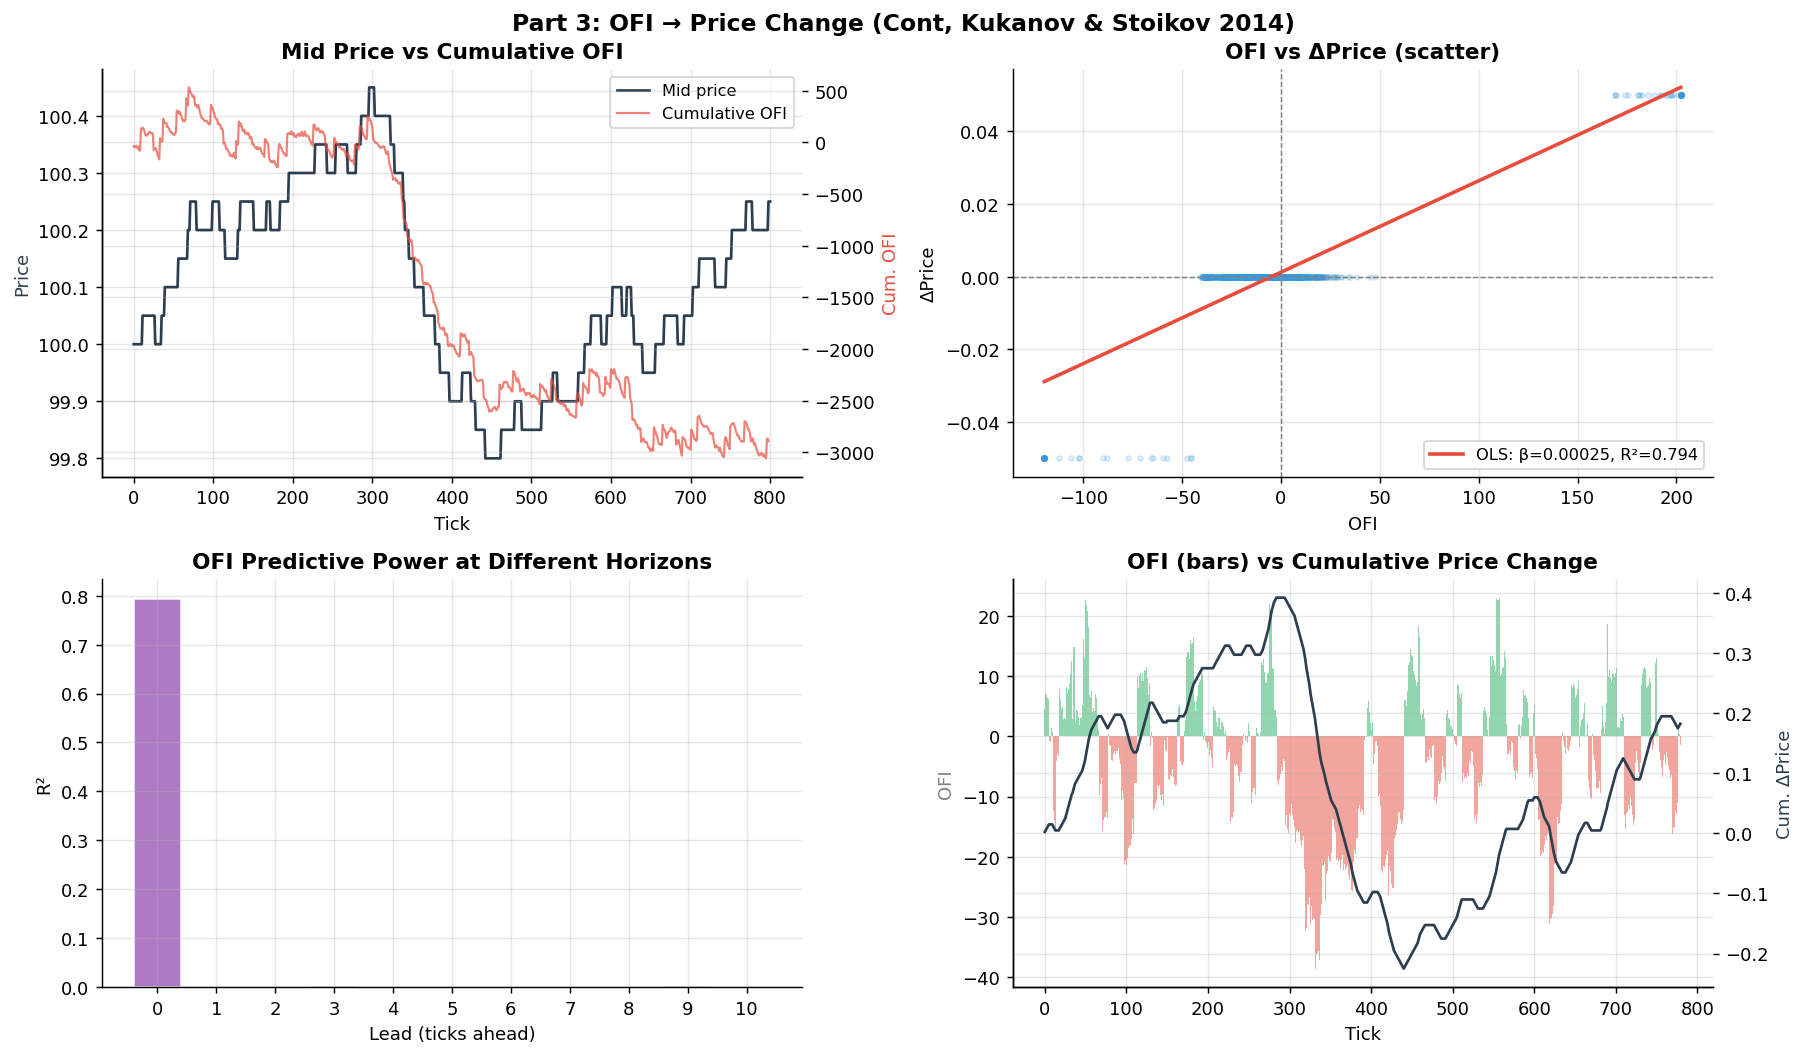

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Mid price and cumulative OFI
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(mid_vals, color="#2c3e50", lw=1.5, label="Mid price")
cum_ofi = ofi_calc.cumulative_ofi()
ax2.plot(cum_ofi, color="#e74c3c", lw=1.2, alpha=0.7, label="Cumulative OFI")
ax.set_title("Mid Price vs Cumulative OFI", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Price", color="#2c3e50")
ax2.set_ylabel("Cum. OFI", color="#e74c3c")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, fontsize=9)

# 2. Scatter: OFI vs ΔPrice
ax = axes[0, 1]
# Clip for visibility
ofi_clip = np.clip(ofi_arr, np.percentile(ofi_arr, 2), np.percentile(ofi_arr, 98))
ax.scatter(ofi_clip, dp_arr, alpha=0.15, s=8, color="#3498db")
x_line = np.linspace(ofi_clip.min(), ofi_clip.max(), 100)
ax.plot(x_line, beta * (x_line - np.mean(ofi_arr)) + np.mean(dp_arr),
        color="#e74c3c", lw=2, label=f"OLS: β={beta:.5f}, R²={r2:.3f}")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_title("OFI vs ΔPrice (scatter)", fontweight="bold")
ax.set_xlabel("OFI")
ax.set_ylabel("ΔPrice")
ax.legend(fontsize=9)

# 3. Lead-lag R²
ax = axes[1, 0]
ax.bar(range(max_lead + 1), lead_r2, color="#9b59b6", alpha=0.8, edgecolor="white")
ax.set_title("OFI Predictive Power at Different Horizons", fontweight="bold")
ax.set_xlabel("Lead (ticks ahead)")
ax.set_ylabel("R²")
ax.set_xticks(range(max_lead + 1))

# 4. OFI time series + price change
ax = axes[1, 1]
ax2 = ax.twinx()
# Rolling OFI (smoothed)
w = 20
ofi_smooth = np.convolve(ofi_arr, np.ones(w)/w, mode="valid")
dp_smooth  = np.convolve(dp_arr,  np.ones(w)/w, mode="valid")
x_range = np.arange(len(ofi_smooth))
ax.bar(x_range, ofi_smooth, width=1, color=np.where(ofi_smooth > 0, "#27ae60", "#e74c3c"),
       alpha=0.5, label="OFI (smoothed)")
ax2.plot(x_range, np.cumsum(dp_smooth), color="#2c3e50", lw=1.5, label="Cum. ΔPrice")
ax.set_title("OFI (bars) vs Cumulative Price Change", fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("OFI", color="gray")
ax2.set_ylabel("Cum. ΔPrice", color="#2c3e50")

plt.tight_layout()
plt.suptitle("Part 3: OFI → Price Change (Cont, Kukanov & Stoikov 2014)", y=1.01, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- OFI có **positive β** và R² > 0 → imbalance trong queue dự báo giá trong cùng tick.
- Predictive power **giảm theo lead** → OFI là short-horizon predictor, không phải dài hạn.
- Cumulative OFI track closely với mid price → tích lũy imbalance = áp lực giá.

---
## Part 4 — Permanent vs Temporary Price Impact

**Almgren-Chriss (2000)** phân tích impact thành:

$$\underbrace{\Delta P_{\text{total}}}_{\text{tổng}} = \underbrace{\lambda \cdot Q}_{\text{permanent}} + \underbrace{\eta \cdot Q}_{\text{temporary}}$$

- **Permanent**: do thông tin — giá không revert về cũ
- **Temporary**: do thanh khoản — giá revert sau khi order hoàn tất

In [22]:
rng4 = np.random.default_rng(21)

# Calibrate từ simulated data
N_impact = 400
lambda_true = 0.0008   # permanent
eta_true    = 0.0015   # temporary

quantities  = rng4.uniform(10, 300, N_impact)
signs       = rng4.choice([-1, 1], N_impact)
sv          = signs * quantities

# True price changes = permanent + temporary + noise
dp_permanent  = lambda_true * sv
dp_temporary  = eta_true    * sv * rng4.uniform(0.5, 1.5, N_impact)   # noisy
dp_total      = dp_permanent + dp_temporary + rng4.normal(0, 0.005, N_impact)

# Price paths
price_path     = 100 + np.cumsum(dp_total)
price_perm     = 100 + np.cumsum(dp_permanent)

# Calibrate model via OLS
model = PriceImpactModel(lambda_=0.001, eta=0.002)
model.calibrate(sv, dp_total)

print(f"True λ (permanent) = {lambda_true:.5f}  |  True η (temporary) = {eta_true:.5f}")
print(f"Calibrated λ (OLS on total ΔP) = {model.lambda_:.5f}  ← captures λ + η·noise")
print()

# Decompose 3 specific large trades
large_orders = [100, 200, 300]
print("Impact decomposition for buy orders:")
print(f"  {'Size':>6}  {'Total':>10}  {'Permanent':>12}  {'Temporary':>12}  {'Perm%':>8}")
for q in large_orders:
    total = model.total_impact(q, sign=1)
    perm  = model.permanent_impact(q, sign=1)
    temp  = model.temporary_impact(q, sign=1)
    print(f"  {q:>6}  {total:>10.4f}  {perm:>12.4f}  {temp:>12.4f}  {perm/total:>8.1%}")

# Implementation shortfall: split parent order Q=500 into 10 child orders
arrival_price = 100.0
total_Q   = 500.0
qs_exec   = np.full(10, total_Q / 10)   # equal slices
sg_exec   = np.ones(10)                  # all buys
IS = model.execution_shortfall(qs_exec, sg_exec, arrival_price)
IS_bps = IS / (arrival_price * total_Q) * 10000
print(f"\nImplementation shortfall (Q={total_Q:.0f}, 10 child orders): {IS:.4f} ({IS_bps:.1f} bps)")

True λ (permanent) = 0.00080  |  True η (temporary) = 0.00150
Calibrated λ (OLS on total ΔP) = 0.00232  ← captures λ + η·noise

Impact decomposition for buy orders:
    Size       Total     Permanent     Temporary     Perm%
     100      0.4317        0.2317        0.2000     53.7%
     200      0.8635        0.4635        0.4000     53.7%
     300      1.2952        0.6952        0.6000     53.7%

Implementation shortfall (Q=500, 10 child orders): 593.6446 (118.7 bps)


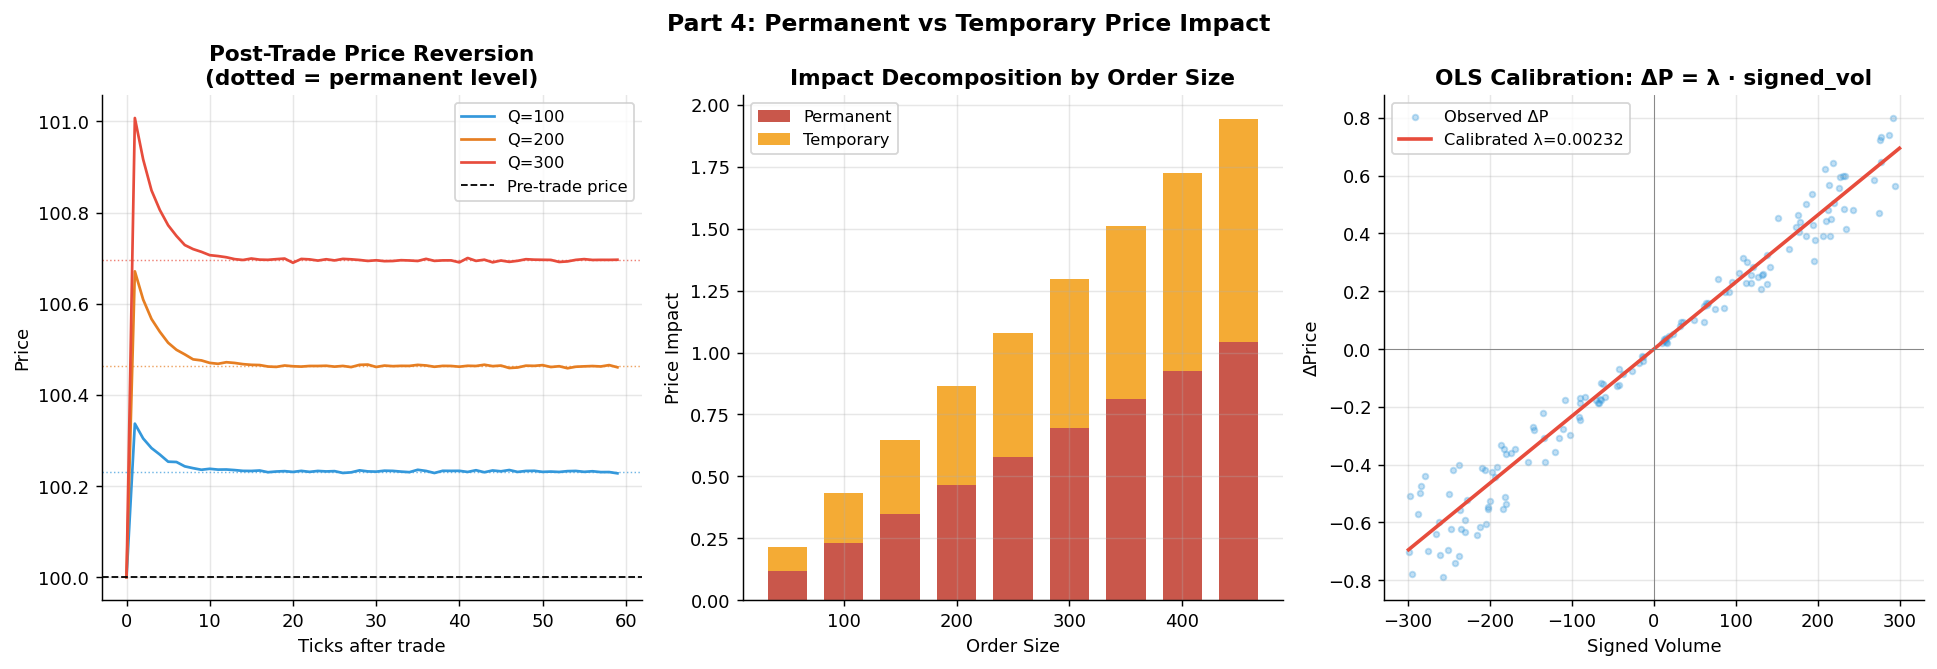

In [23]:
rng4b = np.random.default_rng(99)
T_revert = 60

def simulate_impact_reversion(
    Q: float, lambda_: float, eta: float,
    revert_speed: float = 0.3, noise: float = 0.002
):
    """
    Mô phỏng price path sau một trade lớn Q.
    Temporary impact giảm dần, permanent impact tồn tại.
    """
    perm = lambda_ * Q
    temp = eta * Q
    prices = np.zeros(T_revert)
    prices[0] = 100.0
    temp_remaining = temp
    for t in range(1, T_revert):
        temp_remaining *= (1 - revert_speed)
        prices[t] = 100.0 + perm + temp_remaining + rng4b.normal(0, noise)
    return prices, 100 + perm

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Price reversion after large buy
ax = axes[0]
for Q, color in [(100, "#3498db"), (200, "#e67e22"), (300, "#e74c3c")]:
    prices, perm_level = simulate_impact_reversion(Q, model.lambda_, eta_true)
    ax.plot(prices, lw=1.5, color=color, label=f"Q={Q}")
    ax.axhline(perm_level, lw=0.8, ls=":", color=color, alpha=0.7)
ax.axhline(100.0, color="black", lw=1, ls="--", label="Pre-trade price")
ax.set_title("Post-Trade Price Reversion\n(dotted = permanent level)", fontweight="bold")
ax.set_xlabel("Ticks after trade")
ax.set_ylabel("Price")
ax.legend(fontsize=9)

# 2. Bar chart: permanent vs temporary by size
ax = axes[1]
sizes = np.arange(50, 500, 50)
perms = [model.permanent_impact(q) for q in sizes]
temps = [model.temporary_impact(q) for q in sizes]
ax.bar(sizes, perms, width=35, label="Permanent", color="#c0392b", alpha=0.85)
ax.bar(sizes, temps, width=35, bottom=perms, label="Temporary", color="#f39c12", alpha=0.85)
ax.set_title("Impact Decomposition by Order Size", fontweight="bold")
ax.set_xlabel("Order Size")
ax.set_ylabel("Price Impact")
ax.legend(fontsize=9)

# 3. Calibration: true vs predicted ΔP
ax = axes[2]
dp_pred = model.lambda_ * sv
ax.scatter(sv[:150], dp_total[:150], alpha=0.3, s=10, color="#3498db", label="Observed ΔP")
sv_line = np.linspace(sv.min(), sv.max(), 100)
ax.plot(sv_line, model.lambda_ * sv_line, color="#e74c3c", lw=2, label=f"Calibrated λ={model.lambda_:.5f}")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_title("OLS Calibration: ΔP = λ · signed_vol", fontweight="bold")
ax.set_xlabel("Signed Volume")
ax.set_ylabel("ΔPrice")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 4: Permanent vs Temporary Price Impact", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Permanent impact** = thông tin trong trade. Giá không revert → thị trường đã học được điều gì đó.
- **Temporary impact** = thanh khoản friction. Giá revert về permanent level sau vài ticks.
- **Implementation shortfall** = tổng chi phí của chiến lược execution (permanent + temporary cộng dồn qua nhiều child orders).

---
## Part 5 — Trade Classification: Tick Rule vs Lee-Ready

Khi không có dữ liệu agressor side trực tiếp, phải phân loại trade từ giá:

| Method | Logic | Ưu điểm | Nhược điểm |
|---|---|---|---|
| **Tick Rule** | Price ↑ → BUY | Đơn giản, O(n) | Sai khi giá không đổi |
| **Lee-Ready** | Price > mid → BUY | Chính xác hơn | Cần Level 1 data |

In [24]:
rng5 = np.random.default_rng(55)
N_cls = 500

# Tạo ground-truth trades
true_signs_int = rng5.choice([-1, 1], N_cls, p=[0.48, 0.52])  # slight buy bias
spread_cls     = 0.10
mid_cls        = 100.0 + np.cumsum(rng5.normal(0, 0.03, N_cls))

bid_prices_cls = mid_cls - spread_cls / 2
ask_prices_cls = mid_cls + spread_cls / 2

# Trade prices: takers mostly hit best quote, but ~15% get price improvement
# that pushes execution past mid → Lee-Ready misclassifies these
noise_inside = np.where(
    rng5.uniform(0, 1, N_cls) < 0.85,
    rng5.uniform(0, 0.9, N_cls),    # trade on correct side of mid
    rng5.uniform(1.0, 1.3, N_cls),  # price improvement beyond mid → hard to classify
)
trade_prices_cls = np.where(
    true_signs_int == 1,
    ask_prices_cls - noise_inside * spread_cls / 2,   # buy near ask
    bid_prices_cls + noise_inside * spread_cls / 2,   # sell near bid
)

# Tick Rule
tick_signs = TradeClassifier.tick_rule(list(trade_prices_cls))
tick_int   = np.array([s.value for s in tick_signs])

# Lee-Ready
lr_signs = TradeClassifier.lee_ready(
    list(trade_prices_cls), list(bid_prices_cls), list(ask_prices_cls)
)
lr_int = np.array([s.value for s in lr_signs])

# Accuracy (excluding UNKNOWN = 0)
valid_mask = (tick_int != 0) & (lr_int != 0)
tick_acc = np.mean(tick_int[valid_mask] == true_signs_int[valid_mask])
lr_acc   = np.mean(lr_int[valid_mask]   == true_signs_int[valid_mask])

# BVC (Bulk Volume Classification)
opens_bvc  = mid_cls[:-1]
closes_bvc = mid_cls[1:]
vol_bvc    = np.abs(rng5.normal(200, 50, N_cls - 1))
buy_bvc, sell_bvc = TradeClassifier.bulk_volume_classify(opens_bvc, closes_bvc, vol_bvc)

print(f"Classification Accuracy:")
print(f"  Tick Rule  : {tick_acc:.1%}")
print(f"  Lee-Ready  : {lr_acc:.1%}")
print()
print(f"Confusion matrix (Lee-Ready):")
tp = np.sum((lr_int == 1)  & (true_signs_int == 1))
tn = np.sum((lr_int == -1) & (true_signs_int == -1))
fp = np.sum((lr_int == 1)  & (true_signs_int == -1))
fn = np.sum((lr_int == -1) & (true_signs_int == 1))
print(f"  TP={tp} TN={tn} FP={fp} FN={fn}")
print(f"  Precision={tp/(tp+fp):.1%}  Recall={tp/(tp+fn):.1%}")

Classification Accuracy:
  Tick Rule  : 69.5%
  Lee-Ready  : 84.2%

Confusion matrix (Lee-Ready):
  TP=218 TN=203 FP=36 FN=43
  Precision=85.8%  Recall=83.5%


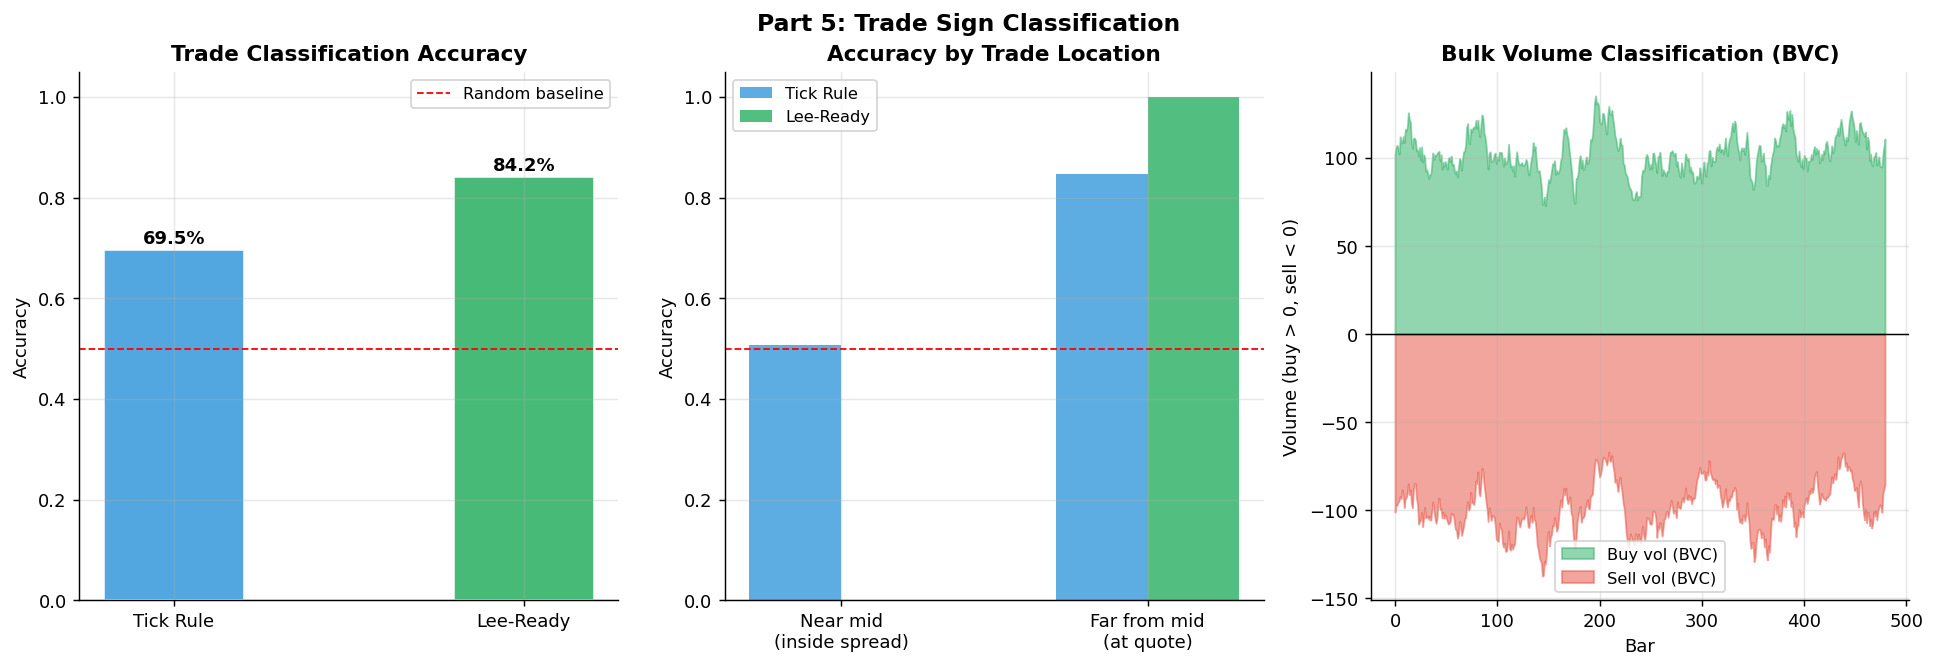

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Accuracy comparison
ax = axes[0]
methods = ["Tick Rule", "Lee-Ready"]
accs = [tick_acc, lr_acc]
bars = ax.bar(methods, accs, color=["#3498db", "#27ae60"], alpha=0.85, width=0.4, edgecolor="white")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{acc:.1%}", ha="center", va="bottom", fontweight="bold")
ax.axhline(0.5, color="red", lw=1, ls="--", label="Random baseline")
ax.set_title("Trade Classification Accuracy", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# 2. Errors by trade type (at mid vs outside)
ax = axes[1]
at_mid = noise_inside >= 1.0   # trades crossing mid → hard to classify
away   = noise_inside < 0.4   # trades clearly at bid/ask

lr_correct_atMid  = np.mean(lr_int[at_mid]  == true_signs_int[at_mid])
lr_correct_away   = np.mean(lr_int[away]    == true_signs_int[away])
tick_correct_atMid = np.mean(tick_int[at_mid] == true_signs_int[at_mid])
tick_correct_away  = np.mean(tick_int[away]   == true_signs_int[away])

x = np.arange(2)
width = 0.3
ax.bar(x - width/2, [tick_correct_atMid, tick_correct_away], width,
       label="Tick Rule", color="#3498db", alpha=0.8)
ax.bar(x + width/2, [lr_correct_atMid, lr_correct_away], width,
       label="Lee-Ready", color="#27ae60", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Near mid\n(inside spread)", "Far from mid\n(at quote)"])
ax.axhline(0.5, color="red", lw=1, ls="--")
ax.set_title("Accuracy by Trade Location", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# 3. BVC buy/sell volume series
ax = axes[2]
w_bvc = 20
buy_smooth  = np.convolve(buy_bvc,  np.ones(w_bvc)/w_bvc, mode="valid")
sell_smooth = np.convolve(sell_bvc, np.ones(w_bvc)/w_bvc, mode="valid")
x_bvc = np.arange(len(buy_smooth))
ax.fill_between(x_bvc, buy_smooth,  alpha=0.5, color="#27ae60", label="Buy vol (BVC)")
ax.fill_between(x_bvc, -sell_smooth, alpha=0.5, color="#e74c3c", label="Sell vol (BVC)")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Bulk Volume Classification (BVC)", fontweight="bold")
ax.set_xlabel("Bar")
ax.set_ylabel("Volume (buy > 0, sell < 0)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 5: Trade Sign Classification", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Nhận xét:**
- **Lee-Ready** vượt trội Tick Rule, đặc biệt khi trades xảy ra rõ ràng tại bid hoặc ask.
- Cả hai đều kém khi trades xảy ra **gần mid** (price improvement) — đây là điểm mù phổ biến.
- **BVC** là giải pháp cho bar-level data không có tick data — dùng return direction để ước lượng buy/sell ratio.

---
## Part 6 — VPIN: Đo Toxic Flow & Dự báo Biến động

**VPIN** (Easley, López de Prado & O'Hara, 2012) là thước đo xác suất informed trading dựa trên volume:

$$\text{VPIN} = \frac{1}{n} \sum_{i=1}^{n} \frac{|V_i^{\text{buy}} - V_i^{\text{sell}}|}{V_\text{bucket}}$$

- VPIN cao → flow độc (toxic) → spread sẽ rộng ra, volatility tăng
- VPIN được dùng như early warning cho flash crashes

In [26]:
rng6 = np.random.default_rng(33)
N_vpin = 600

# 3 regime: normal → toxic (informed surge) → recovery
def get_regime_vpin(t):
    if t < 200: return "normal"
    elif t < 350: return "toxic"
    else: return "recovery"

# Imbalance parameters per regime
imbalance_params = {
    "normal":   0.05,   # small net directional flow
    "toxic":    0.45,   # strong informed buying
    "recovery": 0.10,
}
vol_params_vpin = {"normal": 500, "stressed": 300, "recovery": 400}

vpin_calc = VPINCalculator(bucket_size=800, window=30)

vpin_series = []
price_vpin  = [100.0]
buy_vol_ts  = []
sell_vol_ts = []

for t in range(N_vpin):
    regime = get_regime_vpin(t)
    imb    = imbalance_params[regime]

    total_vol = abs(rng6.normal(500, 100))
    # buy fraction: 0.5 + imbalance + noise
    buy_frac  = np.clip(0.5 + imb + rng6.normal(0, 0.05), 0.05, 0.95)
    buy_vol   = total_vol * buy_frac
    sell_vol  = total_vol * (1 - buy_frac)

    # Price impact from net flow
    net = buy_vol - sell_vol
    price_change = 0.0001 * net + rng6.normal(0, 0.03)
    price_vpin.append(price_vpin[-1] + price_change)

    vpin = vpin_calc.update(buy_vol, sell_vol)
    vpin_series.append(vpin if vpin is not None else np.nan)
    buy_vol_ts.append(buy_vol)
    sell_vol_ts.append(sell_vol)

vpin_arr  = np.array(vpin_series)
price_arr = np.array(price_vpin[1:])

# Realized volatility (rolling 20)
log_rets = np.diff(np.log(np.array(price_vpin) + 1e-10))
rvol = np.array([
    np.std(log_rets[max(0, i-20):i]) if i >= 20 else np.nan
    for i in range(len(log_rets))
])

# VPIN statistics by regime
regimes_arr = [get_regime_vpin(t) for t in range(N_vpin)]
for regime in ["normal", "toxic", "recovery"]:
    mask = np.array([r == regime for r in regimes_arr])
    v = vpin_arr[mask]
    v_valid = v[~np.isnan(v)]
    if len(v_valid) > 0:
        print(f"VPIN {regime:10s}: mean={np.mean(v_valid):.4f}, max={np.max(v_valid):.4f}")

VPIN normal    : mean=0.1076, max=0.1215
VPIN toxic     : mean=0.7412, max=0.8727
VPIN recovery  : mean=0.2693, max=0.8551


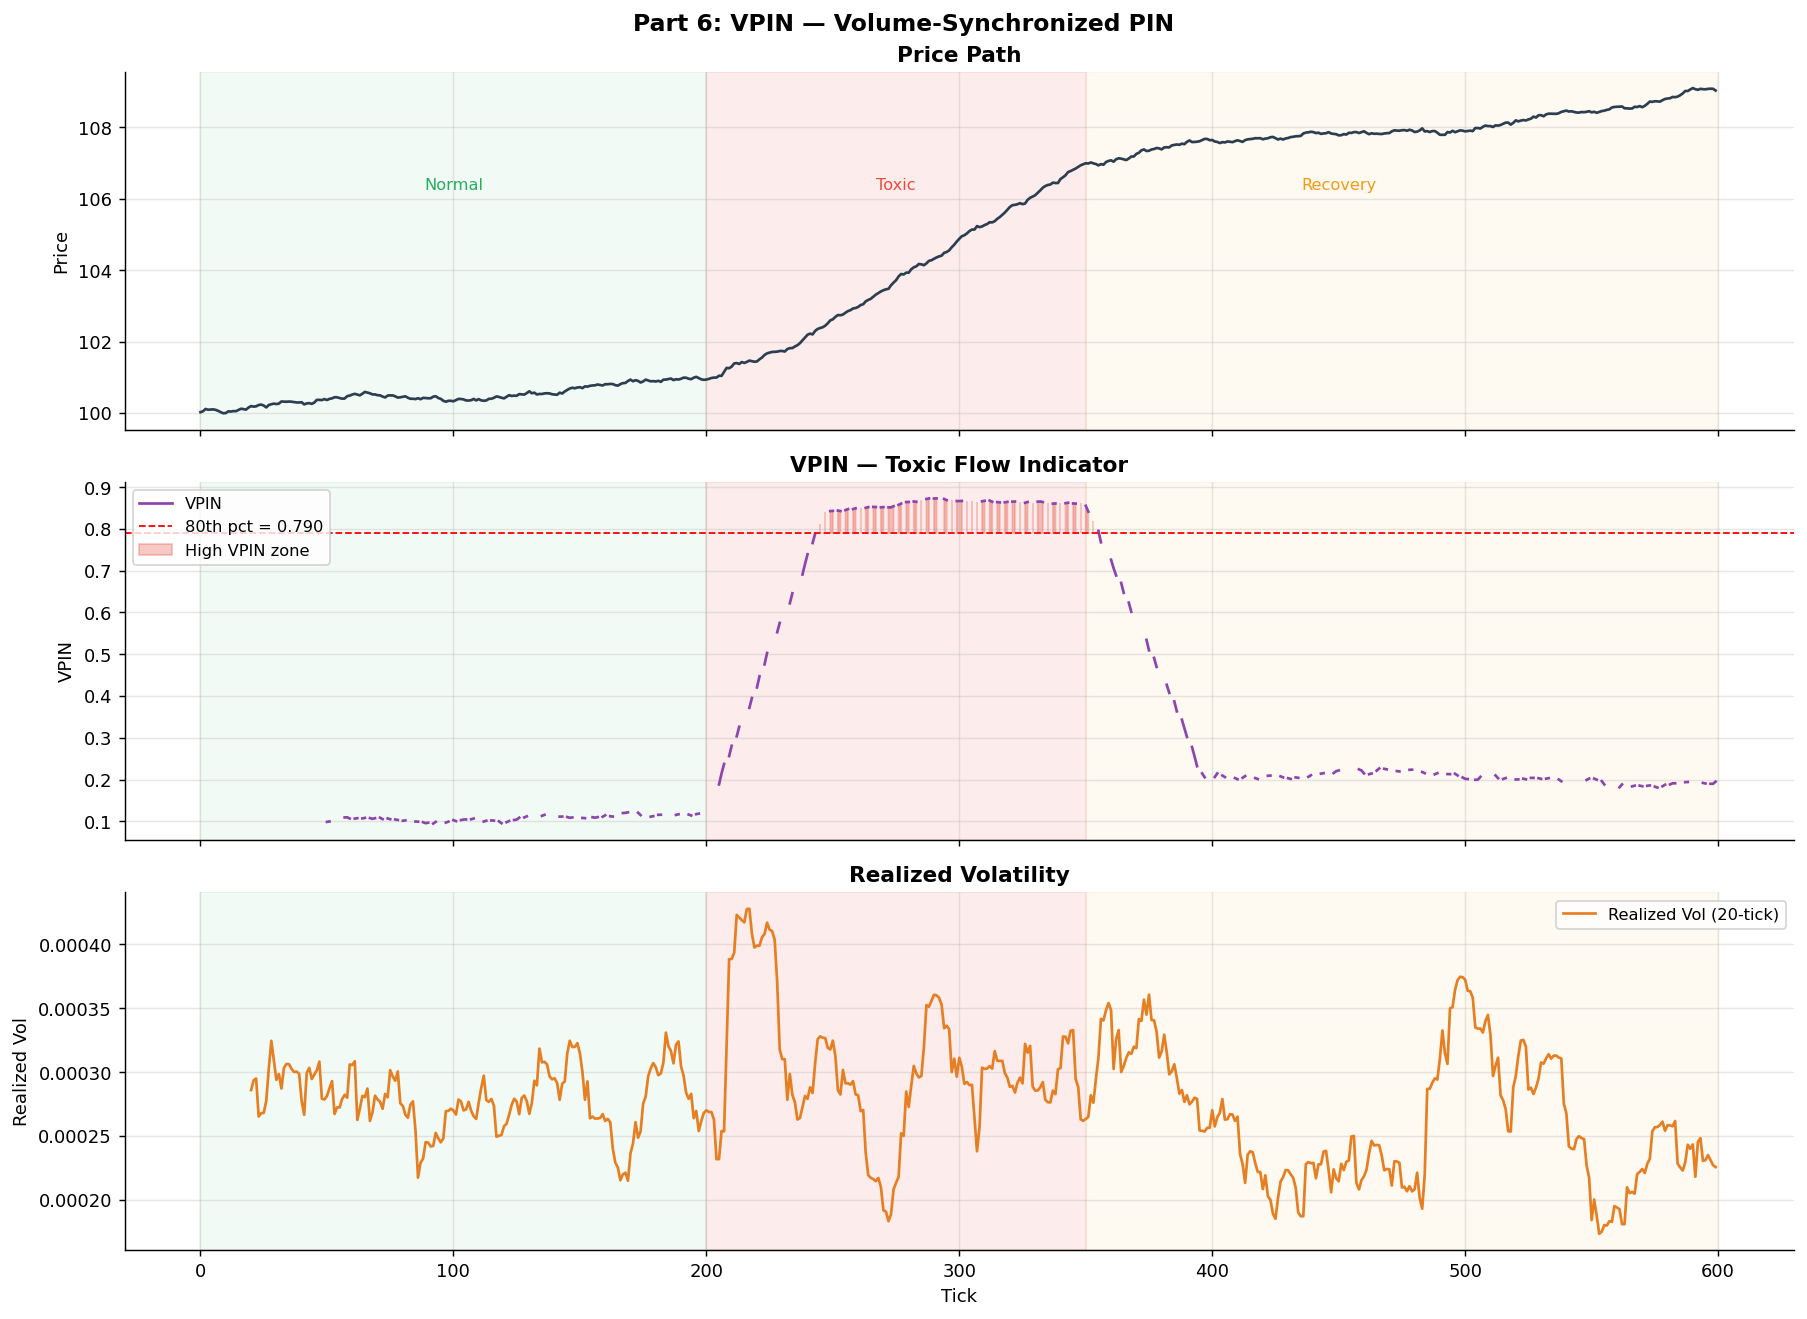

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

t_ax = np.arange(N_vpin)

# Shade regimes
for ax in axes:
    ax.axvspan(0,   200, alpha=0.06, color="#27ae60")
    ax.axvspan(200, 350, alpha=0.10, color="#e74c3c")
    ax.axvspan(350, N_vpin, alpha=0.06, color="#f39c12")

# 1. Price
ax = axes[0]
ax.plot(price_arr, color="#2c3e50", lw=1.5)
ax.set_ylabel("Price")
ax.set_title("Price Path", fontweight="bold")
ax.text(100, ax.get_ylim()[1]*0.97, "Normal",   ha="center", color="#27ae60", fontsize=9)
ax.text(275, ax.get_ylim()[1]*0.97, "Toxic",    ha="center", color="#e74c3c", fontsize=9)
ax.text(450, ax.get_ylim()[1]*0.97, "Recovery", ha="center", color="#f39c12", fontsize=9)

# 2. VPIN
ax = axes[1]
ax.plot(vpin_arr, color="#8e44ad", lw=1.5, label="VPIN")
vpin_threshold = np.nanpercentile(vpin_arr, 80)
ax.axhline(vpin_threshold, color="red", lw=1, ls="--", label=f"80th pct = {vpin_threshold:.3f}")
ax.fill_between(t_ax, vpin_arr, vpin_threshold,
                where=vpin_arr > vpin_threshold,
                alpha=0.3, color="#e74c3c", label="High VPIN zone")
ax.set_ylabel("VPIN")
ax.set_title("VPIN — Toxic Flow Indicator", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")

# 3. Realized Volatility
ax = axes[2]
ax.plot(rvol, color="#e67e22", lw=1.5, label="Realized Vol (20-tick)")
ax.set_ylabel("Realized Vol")
ax.set_xlabel("Tick")
ax.set_title("Realized Volatility", fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Part 6: VPIN — Volume-Synchronized PIN", y=1.01, fontsize=13, fontweight="bold")
plt.show()

In [28]:
# VPIN vs Realized Vol correlation
valid = ~(np.isnan(vpin_arr) | np.isnan(rvol))
if valid.sum() > 10:
    corr = np.corrcoef(vpin_arr[valid], rvol[valid])[0, 1]
    print(f"VPIN ↔ Realized Vol correlation: {corr:.4f}")

# Lead: VPIN at t predicts rvol at t+k
print("\nVPIN lead correlation with future realized vol:")
for lead in [0, 5, 10, 20]:
    if lead == 0:
        v1 = vpin_arr[valid]
        v2 = rvol[valid]
        n  = min(len(v1), len(v2))
        c  = np.corrcoef(v1[:n], v2[:n])[0, 1]
    else:
        v1 = vpin_arr[:-lead]
        v2 = rvol[lead:]
        good = ~(np.isnan(v1) | np.isnan(v2))
        c = np.corrcoef(v1[good], v2[good])[0, 1] if good.sum() > 10 else np.nan
    print(f"  lead={lead:2d}: corr={c:.4f}")

VPIN ↔ Realized Vol correlation: 0.2544

VPIN lead correlation with future realized vol:
  lead= 0: corr=0.2544
  lead= 5: corr=0.2549
  lead=10: corr=0.2426
  lead=20: corr=0.2049


**Nhận xét:**
- VPIN tăng rõ trong **toxic regime** → đo được sự gia tăng informed trading.
- VPIN có **positive lead correlation** với realized vol → leading indicator, không chỉ concurrent.
- Ngưỡng VPIN cao (ví dụ 80th percentile) = tín hiệu cảnh báo sớm cho market stress.

---
## Tổng kết: Cơ chế hình thành giá

| Concept | Kết quả chính | Implication |
|---|---|---|
| **Glosten-Milgrom** | Spread ∝ prob_informed | Spread = phí bảo hiểm adverse selection |
| **Price discovery** | Mid hội tụ về fundamental theo error-correction | Tốc độ phụ thuộc vào tỷ lệ informed traders |
| **OFI → ΔPrice** | β > 0, R² có ý nghĩa, predictive power giảm theo lag | OFI = real-time short-horizon predictor |
| **Permanent vs Temporary** | Perm = information, Temp = liquidity friction | Split order để giảm temporary impact |
| **Trade classification** | Lee-Ready > Tick Rule; cả hai kém ở mid-trades | Cần Level 1 data cho accuracy tốt |
| **VPIN** | Leads realized vol; tăng mạnh trong toxic regime | Early warning cho flash crashes |

### Chuỗi nhân quả trong price formation

```
Private signal (informed)
        ↓
  Order flow imbalance (OFI)
        ↓
  Market maker updates belief  →  Spread widens (adverse selection)
        ↓
  Mid price moves toward fundamental
        ↓
  Permanent impact persists  |  Temporary impact reverts
        ↓
  VPIN rises  →  Volatility rises
```

---
**Notebook tiếp theo:** `04_market_maker_inventory.ipynb` — Avellaneda-Stoikov đầy đủ, PnL attribution, inventory path và risk management của market maker.